| Symbol     | Meaning              | Notes                  |
| :--------- | :------------------- | :--------------------- |
| N          | backbone amide N     | polar, H-bond donor    |
| CA         | alpha carbon         | backbone               |
| C          | carbonyl carbon      | backbone               |
| O          | carbonyl oxygen      | polar, H-bond acceptor |
| CB         | beta carbon          | start of side chain    |
| CG         | gamma carbon         | mid side chain         |
| CD         | delta carbon         | further out            |
| CE         | epsilon carbon       | further out            |
| CZ         | zeta carbon          | terminal or aromatic   |
| NE, ND, NH | side chain nitrogens | donors                 |
| OE, OD     | side chain oxygens   | acceptors              |
| OG         | hydroxyl O           | Ser/Thr                |
| OH         | hydroxyl O           | Tyr                    |
| SG, SD     | sulfur               | Cys, Met               |



| Interaction Type                 | Typical Atom Involvement                                 |
| -------------------------------- | -------------------------------------------------------- |
| **Hydrogen bonds**               | O, N, NE, ND, OE, OD, OG, OH, NH1, NH2, NE2              |
| **Electrostatic (salt bridges)** | NH1/NH2/NE (Arg), NZ (Lys), OE1/OE2 (Glu), OD1/OD2 (Asp) |
| **Hydrophobic contacts**         | CB, CG, CD, CE, CZ (carbons in nonpolar groups)          |
| **π–π stacking / aromatic**      | CD1, CD2, CE1, CE2, CZ (PHE, TYR, TRP, HIS)              |
| **Backbone interactions**        | N, O, CA                                                 |


In [3]:
import pandas as pd
import numpy as np


In [4]:

### ---- CONSTANTS ---- ###

BACKBONE = {"N", "CA", "C", "O"}

AROMATIC = {
    "PHE": frozenset({"CG", "CD1", "CD2", "CE1", "CE2", "CZ"}),
    "TYR": frozenset({"CG", "CD1", "CD2", "CE1", "CE2", "CZ"}),
    "TRP": frozenset({"CG", "CD1", "CD2", "NE1", "CE2", "CE3", "CZ2", "CZ3", "CH2"}),}

CATIONIC_RES = {"ARG", "LYS", "HIS"}
ANIONIC_RES = {"ASP", "GLU"}

POLAR_ATOMS = {"O", "N", "S"}

HBD = {"N", "NE", "NE2", "NH1", "NH2", "OG", "OG1", "OH", "SG"}
HBA = {"O", "OD1", "OD2", "OE1", "OE2", "OG", "OG1", "OH", "NE2", "SG"}

POSITIVE = {
    ("ARG", "NE"), ("ARG", "NH1"), ("ARG", "NH2"),
    ("LYS", "NZ"),
}

NEGATIVE = {
    ("ASP", "OD1"), ("ASP", "OD2"),
    ("GLU", "OE1"), ("GLU", "OE2"),
}

In [5]:

### ---- HELPERS ---- ###

def strip_digits(atom):
    return ''.join([c for c in atom if not c.isdigit()])

def is_backbone(atom):
    return strip_digits(atom) in BACKBONE

def aromatic_atom(res, atom):
    core = strip_digits(atom)
    return res in AROMATIC and core in AROMATIC[res]

def is_cationic(res): return res in CATIONIC_RES
def is_anionic(res): return res in ANIONIC_RES

def is_hbond(row):
    if row.distance > 3.5: return False
    A = strip_digits(row.A_atom); B = strip_digits(row.B_atom)
    return ((A in HBD and B in HBA) or (B in HBD and A in HBA))

    
def is_salt_bridge(row):
    if row.distance > 4.0: return False
    return ((is_cationic(row.A_AA) and is_anionic(row.B_AA)) or
            (is_cationic(row.B_AA) and is_anionic(row.A_AA)))

def is_aromatic_pi(row):
    if row.distance > 5.5: return False
    return aromatic_atom(row.A_AA, row.A_atom) and aromatic_atom(row.B_AA, row.B_atom)

def is_cation_pi(row):
    if row.distance > 6.0: return False
    aromA = aromatic_atom(row.A_AA, row.A_atom)
    aromB = aromatic_atom(row.B_AA, row.B_atom)
    catA = is_cationic(row.A_AA)
    catB = is_cationic(row.B_AA)
    return (catA and aromB) or (catB and aromA)

def is_hydrophobic(row):
    if row.distance > 4.5: return False
    return strip_digits(row.A_atom).startswith("C") and strip_digits(row.B_atom).startswith("C")

def is_sulfur_interaction(row):
    return (strip_digits(row.A_atom) == "S" or strip_digits(row.B_atom) == "S")


def is_same_charge(row):
    """
    True if two residues have the same charge
    and are within salt-bridge distance.
    """
    if row.distance > 4.0: return False

    A = row.A_AA
    B = row.B_AA

    if (A in CATIONIC_RES and B in CATIONIC_RES) or \
       (A in ANIONIC_RES and B in ANIONIC_RES):
        return True

    return False



In [6]:

### ---- MAIN CLASSIFIER ---- ###

def classify_structural(row):
    A_bb = is_backbone(row.A_atom)
    B_bb = is_backbone(row.B_atom)

    if A_bb and B_bb:
        return "backbone–backbone"
    elif A_bb or B_bb:
        return "backbone–sidechain"
    else:
        return "sidechain–sidechain"


def classify_biochemical(row):
    """Return a *single* biochemical interaction based on strict hierarchy."""

    # 1 — salt bridge (most specific)
    if is_salt_bridge(row):
        return "salt bridge"

    # 2 — hydrogen bond
    if is_hbond(row):
        return "hydrogen bond"

    # 3 — pi–pi aromatic stacking
    if is_aromatic_pi(row):
        return "pi–pi"

    # 4 — cation–pi
    if is_cation_pi(row):
        return "cation–pi"

    # 5 — sulfur interactions
    if is_sulfur_interaction(row):
        return "sulfur"

    # 6 — hydrophobic (only if BOTH sides are nonpolar)
    if is_hydrophobic(row):
        return "hydrophobic"

    # 7 — fallback: polar vs vdW
    A = strip_digits(row.A_atom)
    B = strip_digits(row.B_atom)
    if A in POLAR_ATOMS and B in POLAR_ATOMS:
        return "polar"

    return "van der Waals"

# def classify_biochemical(row):
#     """
#     Return a SET of biochemical interaction types (overlapping allowed),
#     EXCEPT same_charge interactions are exclusive.
#     """

#     # Check for same-charge first — it is exclusive
#     if is_same_charge(row):
#         return {"same charge"}

#     # Otherwise, overlapping categories
#     interactions = set()
#     interactions.add("van der Waals")  # baseline

#     # Salt bridge (opposite charges)
#     if is_salt_bridge(row):
#         interactions.update(["salt bridge", "hydrogen bond", "polar"])

#     # Hydrogen bond (non-ionic)
#     if is_hbond(row):
#         interactions.update(["hydrogen bond", "polar"])

#     # Aromatic / hydrophobic
#     if is_aromatic_pi(row):
#         interactions.update(["pi–pi", "hydrophobic"])

#     if is_cation_pi(row):
#         interactions.update(["cation–pi", "hydrophobic"])

#     # Sulfur interactions
#     if is_sulfur_interaction(row):
#         interactions.add("sulfur")

#     # Generic hydrophobic
#     if is_hydrophobic(row):
#         interactions.add("hydrophobic")

#     # Polar fallback
#     A = strip_digits(row.A_atom)
#     B = strip_digits(row.B_atom)
#     if A in POLAR_ATOMS and B in POLAR_ATOMS:
#         interactions.add("polar")

#     return interactions



In [7]:

### ---- APPLY TO DATAFRAME ---- ###

df = pd.read_csv("dataframe_relativesEC6098_proteins_mapped_interactions_w_biomes.tsv", sep='\t')
df["structural_interaction"] = df.apply(classify_structural, axis=1)
df["biochemical_interaction"] = df.apply(classify_biochemical, axis=1)


In [8]:
#check how many non-ionic hydrogen bonds there are
# df["pure_hbond"] = df.biochemical_interaction.apply(
#     lambda x: "hydrogen bond" in x and "salt bridge" not in x
# )

# df["pure_hbond"].sum()

In [9]:
df

,protein,chain_A,A_AA,A_pos,A_atom,chain_B,B_AA,B_pos,B_atom,overlap,distance,interaction,feat_rank,index,gini_imp,seq_position,side,ecosystem_subtype,structural_interaction,biochemical_interaction
0,IMGVR_UViG_3300044270_001180|3300044270|Ga0466...,#2//chain_id='A-53',TRP,551,NH1,#2//chain_id='A-53',GLN,578,OE2,-0.039,2.699,self,1,800_T,5.176608,434.0,A,Oceanic,sidechain–sidechain,van der Waals
1,IMGVR_UViG_3300044270_001180|3300044270|Ga0466...,#2//chain_id='A-53',TRP,551,CD,#2//chain_id='A-53',GLN,578,CD,-0.056,3.816,self,1,800_T,5.176608,434.0,A,Oceanic,sidechain–sidechain,hydrophobic
2,IMGVR_UViG_3300044270_001180|3300044270|Ga0466...,#2//chain_id='A-53',TRP,551,NH1,#2//chain_id='A-53',GLN,578,CD,-0.168,3.688,self,1,800_T,5.176608,434.0,A,Oceanic,sidechain–sidechain,van der Waals
3,IMGVR_UViG_3300044270_001180|3300044270|Ga0466...,#2//chain_id='A-53',TRP,551,CD,#2//chain_id='A-53',GLN,578,OE1,-0.208,3.508,self,1,800_T,5.176608,434.0,A,Oceanic,sidechain–sidechain,van der Waals
4,IMGVR_UViG_3300044270_001180|3300044270|Ga0466...,#2//chain_id='A-53',TRP,551,CG,#2//chain_id='A-53',ASN,604,CG,-0.253,4.013,self,1,800_T,5.176608,434.0,A,Oceanic,sidechain–sidechain,hydrophobic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5815167,IMGVR_UViG_3300047492_000094|3300047492|Ga0485...,#2//chain_id='A-53',CYS,147,CB,#2//chain_id='A-53',VAL,111,CG2,0.262,3.498,self,837,327_P,0.353765,117.0,B,Lake,sidechain–sidechain,hydrophobic
5815168,IMGVR_UViG_3300047492_000094|3300047492|Ga0485...,#2//chain_id='A-53',GLN,113,CG,#2//chain_id='A-53',VAL,111,O,-0.279,3.579,self,837,327_P,0.353765,117.0,B,Lake,backbone–sidechain,van der Waals
5815169,IMGVR_UViG_3300047492_000094|3300047492|Ga0485...,#2//chain_id='A-53',PHE,96,CZ,#2//chain_id='A-53',VAL,111,CD1,-0.385,4.025,self,837,327_P,0.353765,117.0,B,Lake,sidechain–sidechain,hydrophobic
5815170,IMGVR_UViG_3300047492_000094|3300047492|Ga0485...,#2//chain_id='A-53',PHE,96,CE2,#2//chain_id='A-53',VAL,111,CD1,-0.400,4.040,self,837,327_P,0.353765,117.0,B,Lake,sidechain–sidechain,hydrophobic


In [10]:
df = df.explode("biochemical_interaction")
df

,protein,chain_A,A_AA,A_pos,A_atom,chain_B,B_AA,B_pos,B_atom,overlap,distance,interaction,feat_rank,index,gini_imp,seq_position,side,ecosystem_subtype,structural_interaction,biochemical_interaction
0,IMGVR_UViG_3300044270_001180|3300044270|Ga0466...,#2//chain_id='A-53',TRP,551,NH1,#2//chain_id='A-53',GLN,578,OE2,-0.039,2.699,self,1,800_T,5.176608,434.0,A,Oceanic,sidechain–sidechain,van der Waals
1,IMGVR_UViG_3300044270_001180|3300044270|Ga0466...,#2//chain_id='A-53',TRP,551,CD,#2//chain_id='A-53',GLN,578,CD,-0.056,3.816,self,1,800_T,5.176608,434.0,A,Oceanic,sidechain–sidechain,hydrophobic
2,IMGVR_UViG_3300044270_001180|3300044270|Ga0466...,#2//chain_id='A-53',TRP,551,NH1,#2//chain_id='A-53',GLN,578,CD,-0.168,3.688,self,1,800_T,5.176608,434.0,A,Oceanic,sidechain–sidechain,van der Waals
3,IMGVR_UViG_3300044270_001180|3300044270|Ga0466...,#2//chain_id='A-53',TRP,551,CD,#2//chain_id='A-53',GLN,578,OE1,-0.208,3.508,self,1,800_T,5.176608,434.0,A,Oceanic,sidechain–sidechain,van der Waals
4,IMGVR_UViG_3300044270_001180|3300044270|Ga0466...,#2//chain_id='A-53',TRP,551,CG,#2//chain_id='A-53',ASN,604,CG,-0.253,4.013,self,1,800_T,5.176608,434.0,A,Oceanic,sidechain–sidechain,hydrophobic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5815167,IMGVR_UViG_3300047492_000094|3300047492|Ga0485...,#2//chain_id='A-53',CYS,147,CB,#2//chain_id='A-53',VAL,111,CG2,0.262,3.498,self,837,327_P,0.353765,117.0,B,Lake,sidechain–sidechain,hydrophobic
5815168,IMGVR_UViG_3300047492_000094|3300047492|Ga0485...,#2//chain_id='A-53',GLN,113,CG,#2//chain_id='A-53',VAL,111,O,-0.279,3.579,self,837,327_P,0.353765,117.0,B,Lake,backbone–sidechain,van der Waals
5815169,IMGVR_UViG_3300047492_000094|3300047492|Ga0485...,#2//chain_id='A-53',PHE,96,CZ,#2//chain_id='A-53',VAL,111,CD1,-0.385,4.025,self,837,327_P,0.353765,117.0,B,Lake,sidechain–sidechain,hydrophobic
5815170,IMGVR_UViG_3300047492_000094|3300047492|Ga0485...,#2//chain_id='A-53',PHE,96,CE2,#2//chain_id='A-53',VAL,111,CD1,-0.400,4.040,self,837,327_P,0.353765,117.0,B,Lake,sidechain–sidechain,hydrophobic


In [11]:
df_grouped = df.groupby(["protein","interaction",'biochemical_interaction','ecosystem_subtype']).size().reset_index(name='count')
df_grouped

,protein,interaction,biochemical_interaction,ecosystem_subtype,count
0,IMGVR_UViG_3300000213_000001|3300000213|LP_F_1...,inter_capsomer,cation–pi,Oceanic,9
1,IMGVR_UViG_3300000213_000001|3300000213|LP_F_1...,inter_capsomer,hydrogen bond,Oceanic,20
2,IMGVR_UViG_3300000213_000001|3300000213|LP_F_1...,inter_capsomer,hydrophobic,Oceanic,139
3,IMGVR_UViG_3300000213_000001|3300000213|LP_F_1...,inter_capsomer,salt bridge,Oceanic,17
4,IMGVR_UViG_3300000213_000001|3300000213|LP_F_1...,inter_capsomer,van der Waals,Oceanic,169
...,...,...,...,...,...
14374,MGYP005832382619,self,cation–pi,Oceanic,12
14375,MGYP005832382619,self,hydrogen bond,Oceanic,66
14376,MGYP005832382619,self,hydrophobic,Oceanic,1293
14377,MGYP005832382619,self,salt bridge,Oceanic,102


In [12]:
from Bio import SeqIO

length_dict={}

with open("cluster_0_1_mixed_relativesEC6098_MSTA_aa.fa", 'r') as fasta_in:
    records = SeqIO.parse(fasta_in,'fasta')
    for record in records:
        length_dict[record.id] = count = len([True for x in record.seq if x != '-'])

In [13]:
length_df = pd.DataFrame.from_dict(length_dict,orient='index', columns=['length']).reset_index()
length_df

,index,length
0,IMGVR_UViG_3300044270_001180|3300044270|Ga0466...,692
1,IMGVR_UViG_3300017754_000562|3300017754|Ga0181...,541
2,IMGVR_UViG_3300012920_005403|3300012920|Ga0160...,688
3,IMGVR_UViG_3300012775_000125|3300012775|Ga0138...,540
4,IMGVR_UViG_3300009185_000012|3300009185|Ga0114...,434
...,...,...
1101,IMGVR_UViG_3300017785_005588|3300017785|Ga0181...,534
1102,IMGVR_UViG_3300010885_020937|3300010885|Ga0133...,533
1103,IMGVR_UViG_3300048686_000150|3300048686|Ga0485...,534
1104,IMGVR_UViG_3300047511_000074|3300047511|Ga0485...,534


In [14]:
df_grouped_2 = df_grouped.merge(length_df,left_on='protein',right_on='index',how='left')
df_grouped_2['norm_interactions'] = df_grouped_2['count'] / df_grouped_2['length'] * 100
df_grouped_2

,protein,interaction,biochemical_interaction,ecosystem_subtype,count,index,length,norm_interactions
0,IMGVR_UViG_3300000213_000001|3300000213|LP_F_1...,inter_capsomer,cation–pi,Oceanic,9,IMGVR_UViG_3300000213_000001|3300000213|LP_F_1...,530,1.698113
1,IMGVR_UViG_3300000213_000001|3300000213|LP_F_1...,inter_capsomer,hydrogen bond,Oceanic,20,IMGVR_UViG_3300000213_000001|3300000213|LP_F_1...,530,3.773585
2,IMGVR_UViG_3300000213_000001|3300000213|LP_F_1...,inter_capsomer,hydrophobic,Oceanic,139,IMGVR_UViG_3300000213_000001|3300000213|LP_F_1...,530,26.226415
3,IMGVR_UViG_3300000213_000001|3300000213|LP_F_1...,inter_capsomer,salt bridge,Oceanic,17,IMGVR_UViG_3300000213_000001|3300000213|LP_F_1...,530,3.207547
4,IMGVR_UViG_3300000213_000001|3300000213|LP_F_1...,inter_capsomer,van der Waals,Oceanic,169,IMGVR_UViG_3300000213_000001|3300000213|LP_F_1...,530,31.886792
...,...,...,...,...,...,...,...,...
14374,MGYP005832382619,self,cation–pi,Oceanic,12,MGYP005832382619,411,2.919708
14375,MGYP005832382619,self,hydrogen bond,Oceanic,66,MGYP005832382619,411,16.058394
14376,MGYP005832382619,self,hydrophobic,Oceanic,1293,MGYP005832382619,411,314.598540
14377,MGYP005832382619,self,salt bridge,Oceanic,102,MGYP005832382619,411,24.817518


In [15]:
#df_grouped = df_grouped.loc[~((df_grouped['biochemical_interaction'].str.contains('hydrophobic')) | (df_grouped['biochemical_interaction'].str.contains('Waals')))]
#df_grouped = df_grouped.loc[~((df_grouped['interaction'].str.contains('self')))]
df_grouped_sum = df_grouped_2.groupby(["interaction",'biochemical_interaction','ecosystem_subtype'])['norm_interactions'].sum().reset_index()
df_grouped_sum

,interaction,biochemical_interaction,ecosystem_subtype,norm_interactions
0,inter_capsomer,cation–pi,Lake,1346.206247
1,inter_capsomer,cation–pi,Oceanic,421.101650
2,inter_capsomer,hydrogen bond,Lake,2962.429332
3,inter_capsomer,hydrogen bond,Oceanic,961.218881
4,inter_capsomer,hydrophobic,Lake,23486.182505
5,inter_capsomer,hydrophobic,Oceanic,8008.838681
6,inter_capsomer,pi–pi,Lake,0.413223
7,inter_capsomer,pi–pi,Oceanic,0.869426
8,inter_capsomer,salt bridge,Lake,3680.571264
9,inter_capsomer,salt bridge,Oceanic,1195.009593


notes:
divide number of bonds by protein length of each protein
--> 3% of this protein is hydrogren... 
--> make violins

<Figure size 1200x600 with 0 Axes>

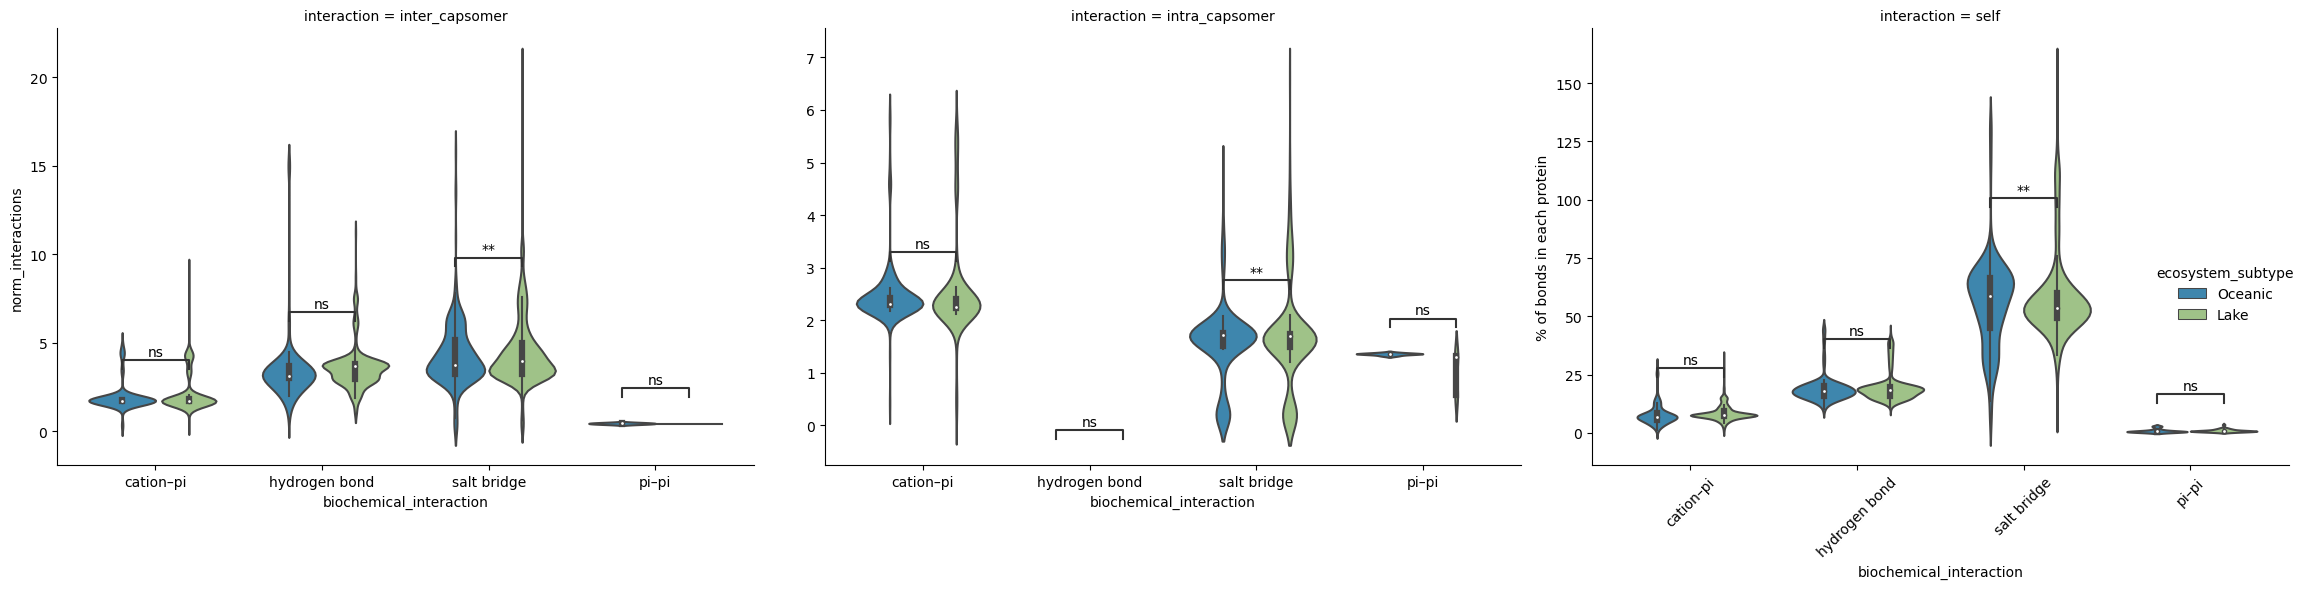

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator


plt.figure(figsize=(12,6))

df_plot = df_grouped_2.loc[~((df_grouped_2['biochemical_interaction'].str.contains('hydrophobic')) | (df_grouped_2['biochemical_interaction'].str.contains('Waals')))]
# df_plot = df_grouped_2.loc[~((df_grouped_2['biochemical_interaction'].str.contains('Waals')))]
g = sns.catplot(
    data=df_plot,
    x='biochemical_interaction',
    y='norm_interactions',
    hue='ecosystem_subtype',
    kind='violin',
    col='interaction',
    sharey=False,
    palette=["#2B8CBF", "#9dcc7e"],
    height=6,
    aspect=1.2
)

# define the comparison: Lake vs Oceanic
pairs = [
    ((biochem, 'Lake'),
        (biochem, 'Oceanic'))
    for biochem in df_plot['biochemical_interaction'].unique()
]

for ax in g.axes.flatten():
    annotator = Annotator(
        ax,
        pairs,
        data=df_plot,
        x='biochemical_interaction',
        y='norm_interactions',
        hue='ecosystem_subtype'
    )
    annotator.configure(
        test='Mann-Whitney',      # t-test_ind or 'Mann-Whitney' or non-parametric (non-normal or untested)
        text_format='star',     # *, **, ***
        loc='inside',
        verbose=0
    )
    annotator.apply_and_annotate()

plt.xticks(rotation=45)
plt.ylabel("% of bonds in each protein")
# plt.title("Structural interaction counts split by ecosystem subtype")
sns.despine()
plt.tight_layout()
plt.show()


In [17]:
df_grouped_2

,protein,interaction,biochemical_interaction,ecosystem_subtype,count,index,length,norm_interactions
0,IMGVR_UViG_3300000213_000001|3300000213|LP_F_1...,inter_capsomer,cation–pi,Oceanic,9,IMGVR_UViG_3300000213_000001|3300000213|LP_F_1...,530,1.698113
1,IMGVR_UViG_3300000213_000001|3300000213|LP_F_1...,inter_capsomer,hydrogen bond,Oceanic,20,IMGVR_UViG_3300000213_000001|3300000213|LP_F_1...,530,3.773585
2,IMGVR_UViG_3300000213_000001|3300000213|LP_F_1...,inter_capsomer,hydrophobic,Oceanic,139,IMGVR_UViG_3300000213_000001|3300000213|LP_F_1...,530,26.226415
3,IMGVR_UViG_3300000213_000001|3300000213|LP_F_1...,inter_capsomer,salt bridge,Oceanic,17,IMGVR_UViG_3300000213_000001|3300000213|LP_F_1...,530,3.207547
4,IMGVR_UViG_3300000213_000001|3300000213|LP_F_1...,inter_capsomer,van der Waals,Oceanic,169,IMGVR_UViG_3300000213_000001|3300000213|LP_F_1...,530,31.886792
...,...,...,...,...,...,...,...,...
14374,MGYP005832382619,self,cation–pi,Oceanic,12,MGYP005832382619,411,2.919708
14375,MGYP005832382619,self,hydrogen bond,Oceanic,66,MGYP005832382619,411,16.058394
14376,MGYP005832382619,self,hydrophobic,Oceanic,1293,MGYP005832382619,411,314.598540
14377,MGYP005832382619,self,salt bridge,Oceanic,102,MGYP005832382619,411,24.817518


/var/folders/6c/dkl_rmf913l9h4s3pys_spm80000gn/T/ipykernel_31813/3575792952.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_grouped_sum_2['structural_norm'] = df_grouped_sum_2.apply(


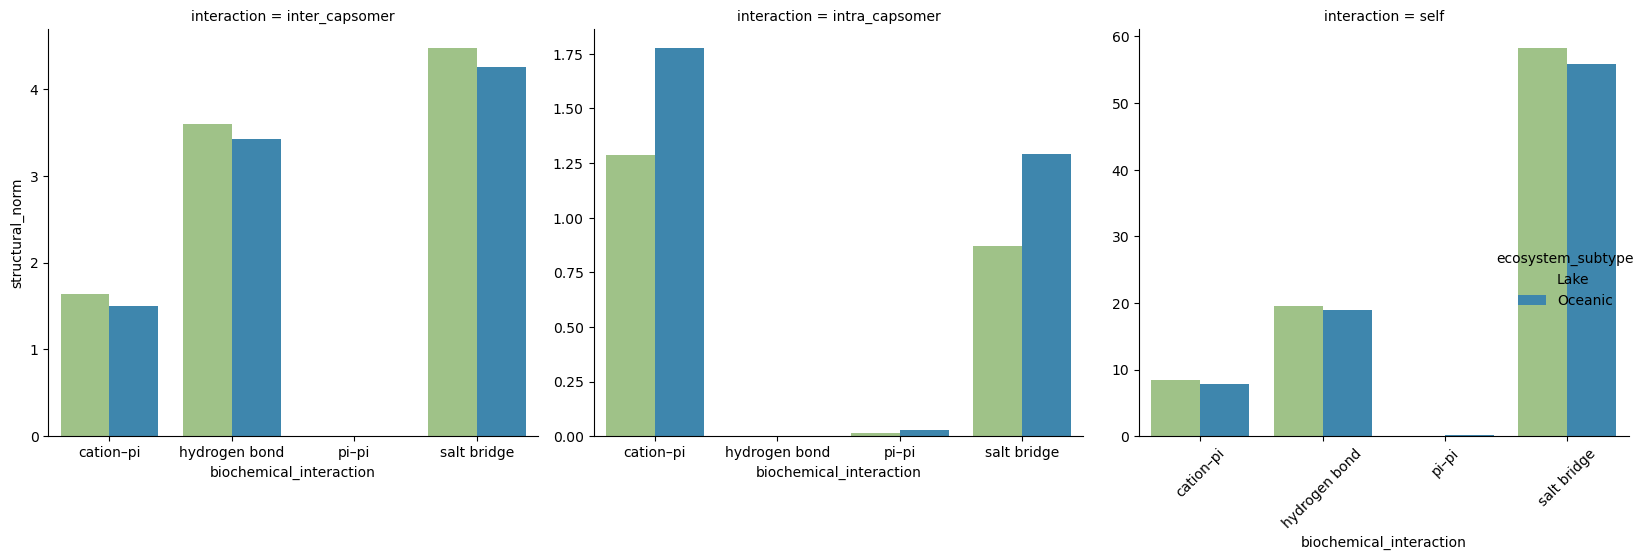

In [18]:

df_grouped_sum_2 = df_grouped_sum.loc[~((df_grouped_sum['biochemical_interaction'].str.contains('hydrophobic')) | (df_grouped_sum['biochemical_interaction'].str.contains('Waals')))]

protein_counts = (
    df_plot[['protein','ecosystem_subtype']]
    .drop_duplicates()
    .groupby('ecosystem_subtype')
    .size()
    .to_dict()
)
df_grouped_sum_2['structural_norm'] = df_grouped_sum_2.apply(
    lambda x: x['norm_interactions'] / protein_counts[x['ecosystem_subtype']],
    axis=1
)

sns.catplot(
    data=df_grouped_sum_2,
    x='biochemical_interaction',
    y='structural_norm',
    hue='ecosystem_subtype',
    palette=["#9dcc7e","#2B8CBF"],
    kind='bar',
    col='interaction',
    sharey=False
)

plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

In [19]:
protein_counts

{'Lake': 824, 'Oceanic': 281}

In [20]:
df_melted = df.melt(
    id_vars=['interaction','biochemical_interaction'],
    value_vars='feat_rank'
)
df_melted

,interaction,biochemical_interaction,variable,value
0,self,van der Waals,feat_rank,1
1,self,hydrophobic,feat_rank,1
2,self,van der Waals,feat_rank,1
3,self,van der Waals,feat_rank,1
4,self,hydrophobic,feat_rank,1
...,...,...,...,...
5815167,self,hydrophobic,feat_rank,837
5815168,self,van der Waals,feat_rank,837
5815169,self,hydrophobic,feat_rank,837
5815170,self,hydrophobic,feat_rank,837


In [21]:
df_reference = pd.read_csv("all_contacts_with_feat_imp.tsv", sep='\t')
df_reference["biochemical_interaction"] = df_reference.apply(classify_biochemical, axis=1)
print(df_reference)
df_melted = df_reference.melt(
    id_vars=['interaction','biochemical_interaction'],
    value_vars='feat_rank'
)
df_melted


                  chain_A A_AA  A_pos A_atom              chain_B B_AA  B_pos  \
0     #2//chain_id='A-53'  LEU    562     CA  #2//chain_id='A-58'  ASP    564   
1     #2//chain_id='A-53'  LEU    562      N  #2//chain_id='A-58'  ASP    564   
2     #2//chain_id='A-53'  LEU    562     CA  #2//chain_id='A-58'  ASP    564   
3     #2//chain_id='A-53'  GLY    561      C  #2//chain_id='A-58'  ASP    564   
4     #2//chain_id='A-53'  LEU    562      N  #2//chain_id='A-58'  ASP    564   
...                   ...  ...    ...    ...                  ...  ...    ...   
6244  #2//chain_id='A-53'  ILE    320    CG1  #2//chain_id='A-54'  ILE    214   
6245  #2//chain_id='A-53'  ASP    336    OD2  #2//chain_id='A-54'  ARG    441   
6246  #2//chain_id='A-53'  PHE    351    CE2  #2//chain_id='A-54'  PRO    447   
6247  #2//chain_id='A-53'  ILE    320    CD1  #2//chain_id='A-54'  VAL    212   
6248  #2//chain_id='A-53'  ASP    336     CB  #2//chain_id='A-53'  LEU    333   

     B_atom  overlap  dista

,interaction,biochemical_interaction,variable,value
0,inter_capsomer,van der Waals,feat_rank,NaN
1,inter_capsomer,van der Waals,feat_rank,NaN
2,inter_capsomer,hydrophobic,feat_rank,NaN
3,inter_capsomer,van der Waals,feat_rank,NaN
4,inter_capsomer,van der Waals,feat_rank,NaN
...,...,...,...,...
6244,inter_capsomer,hydrophobic,feat_rank,NaN
6245,inter_capsomer,salt bridge,feat_rank,349.0
6246,inter_capsomer,hydrophobic,feat_rank,NaN
6247,inter_capsomer,van der Waals,feat_rank,403.0


         interaction biochemical_interaction   variable  value rank_group
0     inter_capsomer           van der Waals  feat_rank    NaN        NaN
1     inter_capsomer           van der Waals  feat_rank    NaN        NaN
2     inter_capsomer             hydrophobic  feat_rank    NaN        NaN
3     inter_capsomer           van der Waals  feat_rank    NaN        NaN
4     inter_capsomer           van der Waals  feat_rank    NaN        NaN
...              ...                     ...        ...    ...        ...
6244  inter_capsomer             hydrophobic  feat_rank    NaN        NaN
6245  inter_capsomer             salt bridge  feat_rank  349.0    340–350
6246  inter_capsomer             hydrophobic  feat_rank    NaN        NaN
6247  inter_capsomer           van der Waals  feat_rank  403.0    400–410
6248            self           van der Waals  feat_rank  295.0    290–300

[6249 rows x 5 columns]


/var/folders/6c/dkl_rmf913l9h4s3pys_spm80000gn/T/ipykernel_31813/1144646238.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['biochemical_interaction', 'rank_group'])
/var/folders/6c/dkl_rmf913l9h4s3pys_spm80000gn/T/ipykernel_31813/1144646238.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_df['fraction'] = count_df.groupby('rank_group')['count'].transform(lambda x: x / x.sum())


<Figure size 1500x600 with 0 Axes>

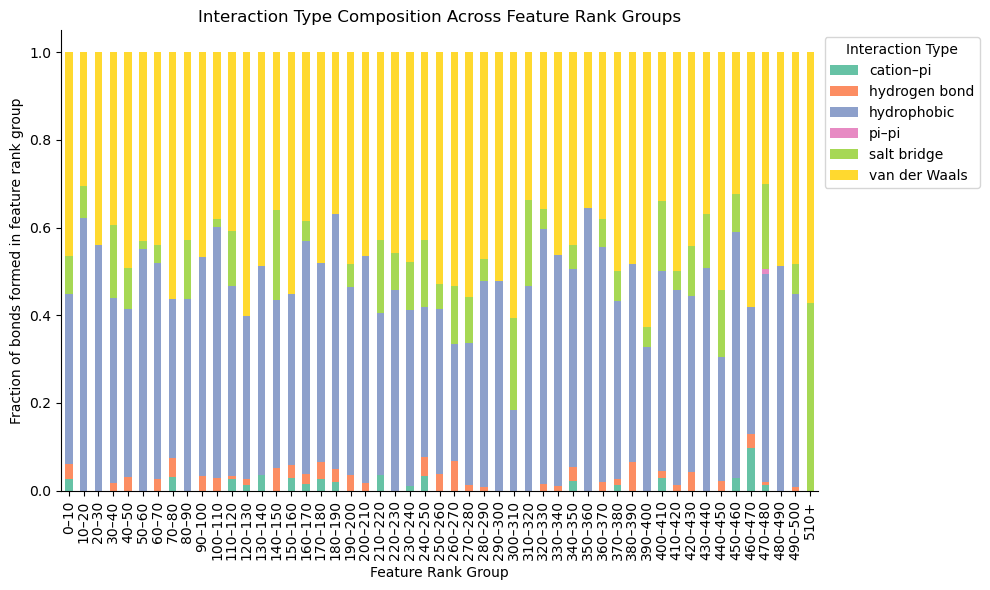

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define bins: 0–20, 20–40, 40–60, ... up to 500, then 500+
bins = list(np.arange(0, 510, 10)) + [float('inf')]
labels = [f"{i}–{i+10}" for i in range(0, 500, 10)] + ["510+"]

df_melted['rank_group'] = pd.cut(df_melted['value'], bins=bins, labels=labels, right=True)
print(df_melted)
# Count how many residues fall into each (interaction, rank_group)
count_df = (
    df_melted
    .groupby(['biochemical_interaction', 'rank_group'])
    .size()
    .reset_index(name='count')
)

# Normalize by interaction type to show relative proportions
count_df['fraction'] = count_df.groupby('rank_group')['count'].transform(lambda x: x / x.sum())

pivot_df = count_df.pivot(index='rank_group', columns='biochemical_interaction', values='fraction').fillna(0)

plt.figure(figsize=(15,6))

pivot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=sns.color_palette('Set2', n_colors=pivot_df.shape[1])
)
plt.ylabel('Fraction of bonds formed in feature rank group')
plt.xlabel('Feature Rank Group')
plt.title('Interaction Type Composition Across Feature Rank Groups')
plt.legend(title='Interaction Type', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

In [28]:
pivot_df

biochemical_interaction,cation–pi,hydrogen bond,hydrophobic,pi–pi,salt bridge,van der Waals
rank_group,,,,,,
0–10,0.025862,0.034483,0.387931,0.0000,0.086207,0.465517
10–20,0.000000,0.000000,0.622449,0.0000,0.071429,0.306122
20–30,0.000000,0.000000,0.561404,0.0000,0.000000,0.438596
30–40,0.000000,0.018349,0.422018,0.0000,0.165138,0.394495
40–50,0.000000,0.030769,0.384615,0.0000,0.092308,0.492308
50–60,0.000000,0.000000,0.551724,0.0000,0.017241,0.431034
60–70,0.000000,0.026667,0.493333,0.0000,0.040000,0.440000
70–80,0.031915,0.042553,0.361702,0.0000,0.000000,0.563830
80–90,0.000000,0.000000,0.436893,0.0000,0.135922,0.427184


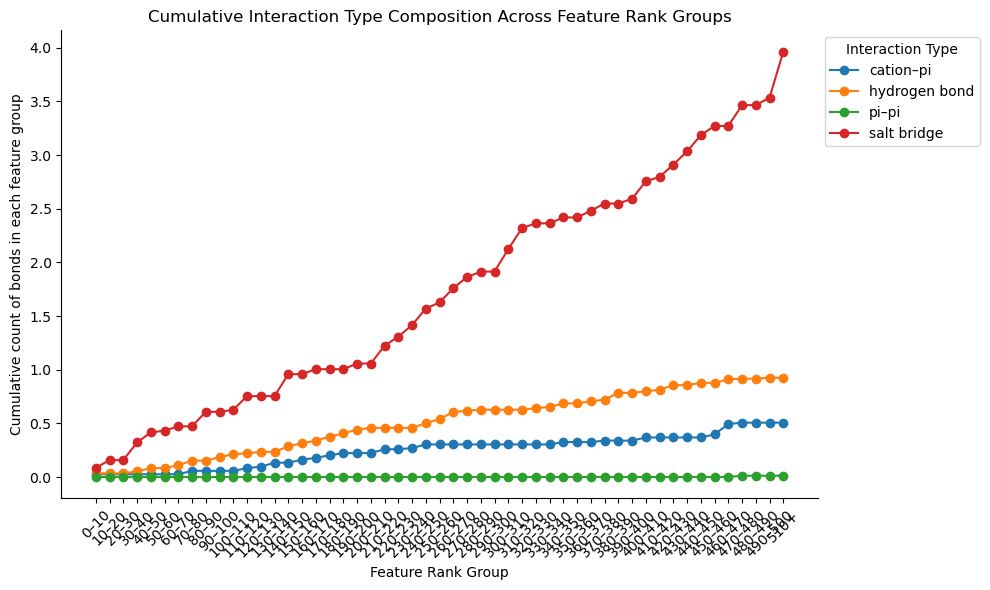

In [31]:

# scale to the max of each bond type**

cumulative_df = pivot_df.cumsum()
plt.figure(figsize=(10,6))
cumulative_fraction_df_smoothed = cumulative_df.rolling(2, min_periods=1).mean()

for interaction in cumulative_df.columns:
    if interaction not in ['hydrophobic','van der Waals']:
        plt.plot(
            cumulative_df.index, 
            cumulative_df[interaction],
            marker='o',
            label=interaction
        )

plt.ylabel('Cumulative count of bonds in each feature group')
plt.xlabel('Feature Rank Group')
plt.title('Cumulative Interaction Type Composition Across Feature Rank Groups')
plt.xticks(rotation=45)
plt.legend(title='Interaction Type', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

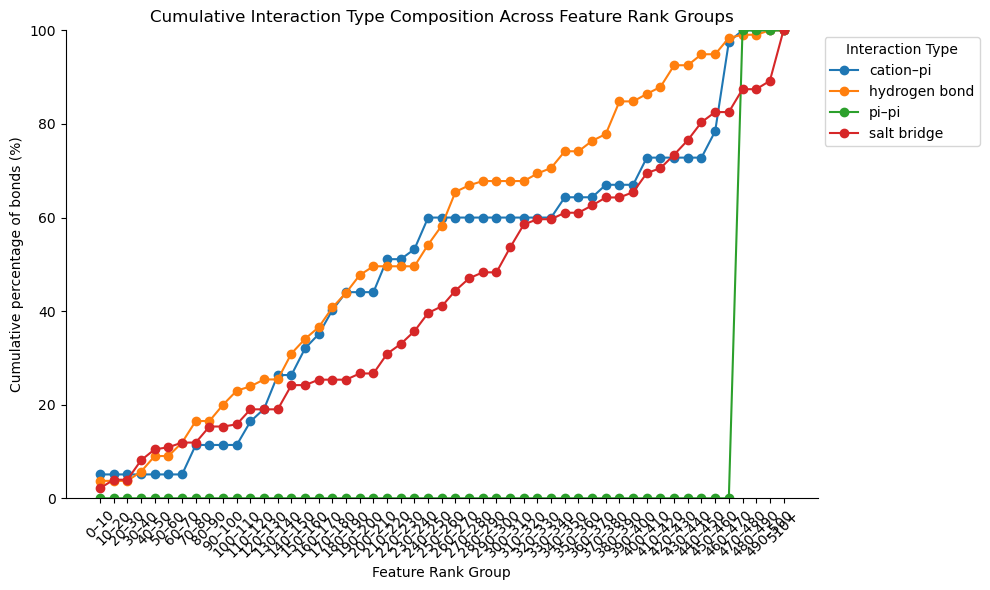

In [32]:
# cumulative sums
cumulative_df = pivot_df.cumsum()

# normalize each interaction so it ends at 100%
cumulative_percent_df = cumulative_df.div(cumulative_df.iloc[-1]) * 100

plt.figure(figsize=(10, 6))

for interaction in cumulative_percent_df.columns:
    if interaction not in ['hydrophobic', 'van der Waals']:
        plt.plot(
            cumulative_percent_df.index,
            cumulative_percent_df[interaction],
            marker='o',
            label=interaction
        )

plt.ylabel('Cumulative percentage of bonds (%)')
plt.xlabel('Feature Rank Group')
plt.title('Cumulative Interaction Type Composition Across Feature Rank Groups')
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.legend(title='Interaction Type', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()
